# Individual Energy-Profile Prediction — curve-approach evaluation

The per-activity **individual curve** prediction benchmark (Baseline, ML DTW,
ML + Ext. Factors, Seq2Seq, …) — the same evaluation as in `results_latex_table`,
extracted on its own.

- Source: `curve_eval_results.parquet` (per-curve records with an **Activity**
  dimension, unlike the `summary_train_test` file the old notebook used).
- Granularity: aggregated **process × activity × sensor**, then across those with
  the **median** (metrics: sMAE, sRMSE, WAPE).
- One table **per process** (all methods) + one **aggregated** table (all
  processes), both as styled tables and LaTeX.
- **Boxplots** of the aggregated per-(process, activity, sensor) values, in the
  same style as the sMAE boxplot in `results_latex_table`.

In [1]:
# ── Config ────────────────────────────────────────────────────────────────────
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from IPython.display import display, Markdown

EXPERIMENT = 960
SPLIT      = 'TEST'                       # 'TEST' or 'TRAIN'
METRICS    = ['sMAE', 'sRMSE', 'WAPE']    # WAPE is a percentage
BOX_METRIC = 'sMAE'                       # metric for the boxplots
EXCLUDE_APPROACHES = []                   # e.g. ['ML DTW + Linear Decode'] to drop variants
SAVE_LATEX = True

results_root = Path('..') / 'results'
runs = sorted([d for d in results_root.iterdir()
               if d.is_dir() and d.name.startswith(f'experiment_{EXPERIMENT}_')])
assert runs, f'No runs for experiment {EXPERIMENT}'
run_dir = runs[-1]
print('Using run:', run_dir.name)

Using run: experiment_960_20260721_163605


In [2]:
# ── Load + aggregate to (process, activity, sensor, approach) ────────────────
raw = pd.read_parquet(run_dir / 'curve_eval_results.parquet')
raw = raw[raw['Split'] == SPLIT]
if EXCLUDE_APPROACHES:
    raw = raw[~raw['Approach'].isin(EXCLUDE_APPROACHES)]
print(f'{len(raw):,} per-curve rows | approaches: {raw["Approach"].nunique()} | '
      f'processes: {sorted(raw["Process"].unique())}')

# Stage 1: one value per (process, activity, sensor, approach) = median over its curves
combo = (raw.groupby(['Process', 'Activity', 'Sensor', 'Approach'])[METRICS]
            .median().reset_index())
print('per (process, activity, sensor, approach) rows:', len(combo))

352,328 per-curve rows | approaches: 13 | processes: ['process_1', 'process_2', 'process_3', 'process_4_1', 'process_4_2', 'process_5']
per (process, activity, sensor, approach) rows: 6768


In [3]:
# ── Table helpers (bold best per column; lower = better) ─────────────────────
def approach_table(df_combo):
    # median across (activity, sensor[, process]) per approach
    t = df_combo.groupby('Approach')[METRICS].median()
    return t.sort_values(BOX_METRIC)          # best (lowest) first

def style_table(t):
    return (t.style.format({m: '{:.3f}' for m in t.columns}, na_rep='—')
             .highlight_min(axis=0, props='font-weight:700;background-color:#d6ecff;')
             .set_caption(f'{SPLIT} — median over process×activity×sensor; lower = better'))

def to_latex(t, caption, label):
    s = pd.DataFrame(index=t.index, columns=t.columns, dtype=object)
    for col in t.columns:
        vals = t[col].dropna(); best = vals.min() if not vals.empty else None
        for idx in t.index:
            v = t.loc[idx, col]
            s.loc[idx, col] = ('' if pd.isna(v) else
                               (r'\textbf{' + f'{v:.3f}' + '}') if (best is not None and abs(v-best) < 1e-6)
                               else f'{v:.3f}')
    latex = s.to_latex(escape=False, column_format='l|' + '|'.join(['c']*len(t.columns)),
                       caption=caption, label=label, position='H')
    return latex.replace('_', r'\_')

## 1 · Aggregated — all processes

In [4]:
agg = approach_table(combo)
display(style_table(agg))

,sMAE,sRMSE,WAPE
Approach,,,
ML Prev Act (no Ext.),1.452,1.661,6.942
ML + Ext. Factors + Prev Act,1.455,1.714,7.250
DTW + Seq2Seq + Prev Act (no Ext.),1.840,2.058,9.361
Baseline,1.968,2.132,9.848
DTW + Seq2Seq + Ext. Factors + Prev Act,2.123,2.314,10.828
ML DTW,2.234,2.453,12.343
DTW + Seq2Seq,2.357,2.470,13.978
Seq2Seq only (no DTW),2.609,2.787,14.704
ML only (no DTW),2.618,2.794,14.322


## 2 · Per process (all methods)

In [5]:
per_process = {}
for proc in sorted(combo['Process'].unique()):
    t = approach_table(combo[combo['Process'] == proc])
    per_process[proc] = t
    display(Markdown(f'### {proc}'))
    display(style_table(t))

### process_1

,sMAE,sRMSE,WAPE
Approach,,,
ML Prev Act (no Ext.) (autoreg),0.297,1.010,37.231
DTW + Ext. Factors + Prev Act (autoreg),0.297,0.979,36.313
ML + Ext. Factors + Prev Act,0.297,0.993,15.294
ML Prev Act (no Ext.),0.297,1.010,12.109
ML only (no DTW),0.325,1.017,18.506
ML DTW,0.330,1.008,14.904
DTW + Seq2Seq,0.385,1.005,15.055
Baseline,0.396,1.041,14.893
DTW + Seq2Seq + Prev Act (no Ext.),0.465,0.948,22.598


### process_2

,sMAE,sRMSE,WAPE
Approach,,,
ML Prev Act (no Ext.),0.358,0.735,23.777
ML + Ext. Factors + Prev Act,0.363,0.800,28.173
DTW + Ext. Factors + Prev Act (autoreg),0.386,0.602,47.644
ML Prev Act (no Ext.) (autoreg),0.389,0.607,47.644
ML DTW,0.418,0.813,29.863
DTW + Seq2Seq,0.538,0.946,41.033
Baseline,0.585,1.009,36.027
DTW + Seq2Seq + Ext. Factors + Prev Act,0.667,0.893,50.673
DTW + Seq2Seq + Prev Act (no Ext.),0.670,0.970,50.673


### process_3

...

,sMAE,sRMSE,WAPE
Approach,,,
ML Prev Act (no Ext.),2.348,2.575,7.231
Baseline,2.370,2.526,7.910
ML + Ext. Factors + Prev Act,2.473,2.596,8.436
DTW + Seq2Seq + Ext. Factors + Prev Act,2.890,3.091,10.828
DTW + Seq2Seq + Prev Act (no Ext.),3.012,3.171,9.723
DTW + Seq2Seq,3.388,3.516,14.188
Seq2Seq only (no DTW),3.451,3.595,13.368
ML DTW,3.538,3.677,13.415
ML only (no DTW),3.593,3.732,13.734


### process_4_2

,sMAE,sRMSE,WAPE
Approach,,,
ML + Ext. Factors + Prev Act,3.088,3.217,11.943
ML Prev Act (no Ext.),3.138,3.315,10.392
DTW + Seq2Seq + Ext. Factors + Prev Act,3.324,3.562,15.667
Baseline,3.810,3.942,16.832
DTW + Seq2Seq + Prev Act (no Ext.),3.895,4.104,17.393
Seq2Seq only (no DTW),4.956,5.002,24.848
ML only (no DTW),4.999,5.029,23.337
ML DTW,5.382,5.459,21.837
DTW + Seq2Seq,5.524,5.588,25.375


### process_5

,sMAE,sRMSE,WAPE
Approach,,,
ML Prev Act (no Ext.),1.141,1.364,3.493
ML + Ext. Factors + Prev Act,1.186,1.415,3.522
DTW + Seq2Seq + Prev Act (no Ext.),1.613,1.856,5.103
ML DTW,1.829,2.044,5.271
DTW + Seq2Seq,1.957,2.162,6.882
DTW + Seq2Seq + Ext. Factors + Prev Act,1.990,2.189,6.533
Baseline,2.118,2.299,5.784
ML only (no DTW),2.342,2.552,7.096
Seq2Seq only (no DTW),2.584,2.787,8.934


## 3 · LaTeX

In [6]:
out = run_dir / 'process_metrics_tables'
if SAVE_LATEX: out.mkdir(exist_ok=True)

tex_agg = to_latex(agg,
    caption=(f'Individual energy-profile prediction ({SPLIT} set), all processes. Median over '
             r'(process, activity, sensor) of each curve metric; lower is better. '
             r'\textbf{Bold} = best approach per metric.'),
    label=f'tab:individual_profile_all_{EXPERIMENT}')
if SAVE_LATEX: (out / 'individual_profile_all.tex').write_text(tex_agg)
print('% ===== ALL PROCESSES ====='); print(tex_agg)

for proc, t in per_process.items():
    tex = to_latex(t,
        caption=(f'Individual energy-profile prediction for {proc} ({SPLIT} set). Median over '
                 r'(activity, sensor) of each curve metric; lower is better. '
                 r'\textbf{Bold} = best approach per metric.'),
        label=f'tab:individual_profile_{proc}_{EXPERIMENT}')
    if SAVE_LATEX: (out / f'individual_profile_{proc}.tex').write_text(tex)
    print(f'\n% ===== {proc} ====='); print(tex)
if SAVE_LATEX: print('\nSaved .tex to', out)

% ===== ALL PROCESSES =====
\begin{table}[H]
\caption{Individual energy-profile prediction (TEST set), all processes. Median over (process, activity, sensor) of each curve metric; lower is better. \textbf{Bold} = best approach per metric.}
\label{tab:individual\_profile\_all\_960}
\begin{tabular}{l|c|c|c}
\toprule
 & sMAE & sRMSE & WAPE \\
Approach &  &  &  \\
\midrule
ML Prev Act (no Ext.) & \textbf{1.452} & \textbf{1.661} & \textbf{6.942} \\
ML + Ext. Factors + Prev Act & 1.455 & 1.714 & 7.250 \\
DTW + Seq2Seq + Prev Act (no Ext.) & 1.840 & 2.058 & 9.361 \\
Baseline & 1.968 & 2.132 & 9.848 \\
DTW + Seq2Seq + Ext. Factors + Prev Act & 2.123 & 2.314 & 10.828 \\
ML DTW & 2.234 & 2.453 & 12.343 \\
DTW + Seq2Seq & 2.357 & 2.470 & 13.978 \\
Seq2Seq only (no DTW) & 2.609 & 2.787 & 14.704 \\
ML only (no DTW) & 2.618 & 2.794 & 14.322 \\
DTW + Ext. Factors + Prev Act (autoreg) & 2.946 & 3.143 & 13.005 \\
ML Prev Act (no Ext.) (autoreg) & 3.181 & 3.335 & 13.311 \\
DTW + Seq2Seq + Prev Act (no E

## 4 · Boxplot — aggregated per (process, activity, sensor)

Same style as the sMAE boxplot in `results_latex_table`: one box per approach over
all (process, activity, sensor) values, sorted best-at-top, x-axis capped near the
95th percentile.

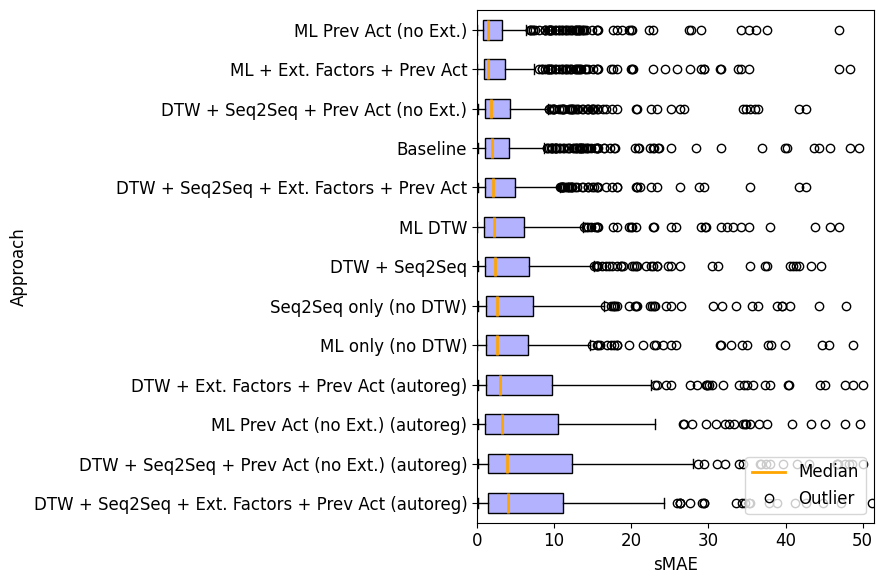

Saved: visuals/individual_profile_sMAE_boxplot.pdf


In [7]:
plt.rcParams.update({'font.size': 12})
df_box = combo[~combo['Approach'].isin(EXCLUDE_APPROACHES)]
box_order = df_box.groupby('Approach')[BOX_METRIC].median().sort_values(ascending=False).index.tolist()
data = [df_box.loc[df_box['Approach'] == a, BOX_METRIC].dropna().values for a in box_order]

fig, ax = plt.subplots(figsize=(9, 6))
bplot = ax.boxplot(data, tick_labels=box_order, showfliers=True, vert=False,
                   patch_artist=True, medianprops=dict(color='orange', linewidth=2))
blue_rgba = mcolors.to_rgba('blue', alpha=0.3)
for patch in bplot['boxes']:
    patch.set_facecolor(blue_rgba); patch.set_edgecolor('black')
all_vals = np.concatenate([d for d in data if len(d)])
ax.set_xlim(0, np.percentile(all_vals, 95) * 1.3)
ax.set_xlabel(BOX_METRIC); ax.set_ylabel('Approach')
ax.legend(handles=[Line2D([0],[0],color='orange',lw=2,label='Median'),
                   Line2D([0],[0],marker='o',color='w',markeredgecolor='black',
                          markerfacecolor='none',markersize=6,label='Outlier')], loc='lower right')
fig.tight_layout()
Path('visuals').mkdir(exist_ok=True)
fig.savefig(f'visuals/individual_profile_{BOX_METRIC}_boxplot.pdf', dpi=300, bbox_inches='tight')
(run_dir/'plots').mkdir(exist_ok=True)
fig.savefig(run_dir/'plots'/f'individual_profile_{BOX_METRIC}_boxplot.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: visuals/individual_profile_{BOX_METRIC}_boxplot.pdf')

### Boxplots for every metric

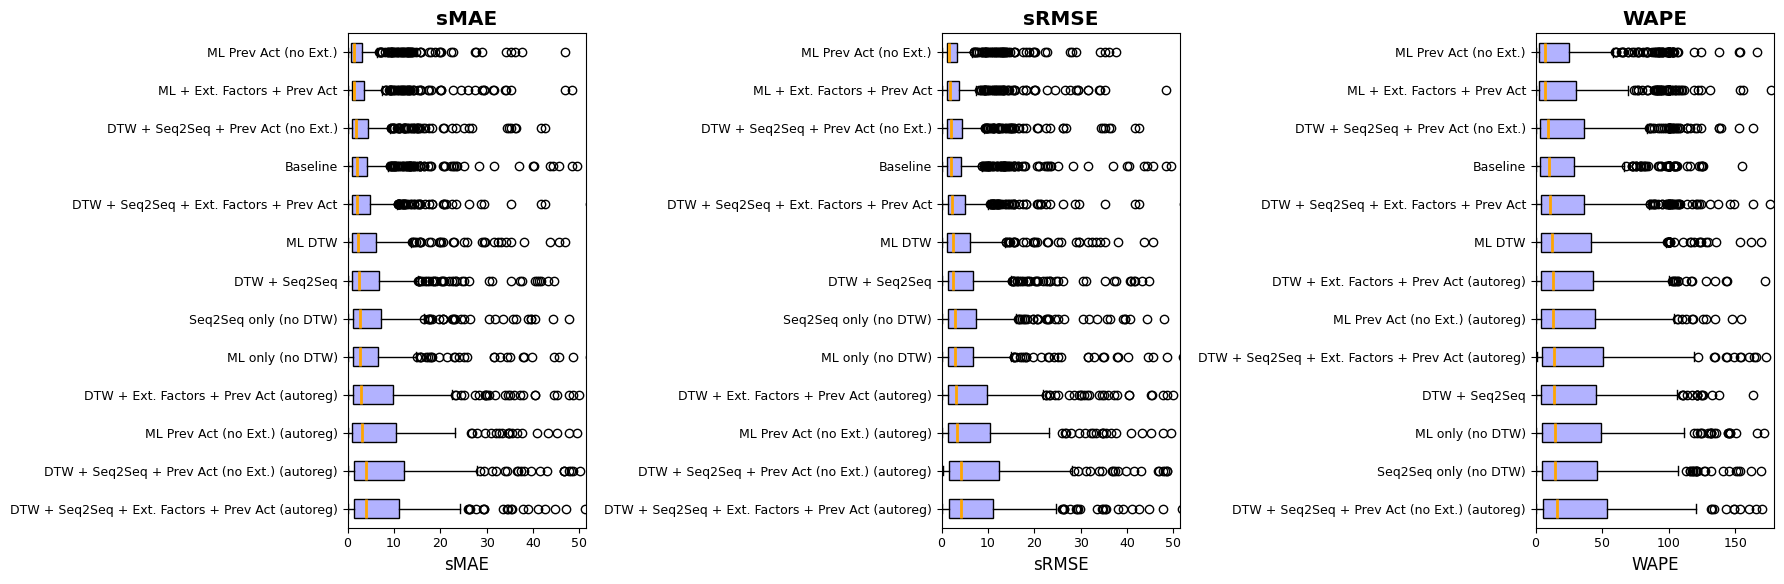

In [8]:
metrics = METRICS
fig, axes = plt.subplots(1, len(metrics), figsize=(6*len(metrics), 6))
axes = np.atleast_1d(axes)
for ax, metric in zip(axes, metrics):
    order = df_box.groupby('Approach')[metric].median().sort_values(ascending=False).index.tolist()
    data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in order]
    bp = ax.boxplot(data, tick_labels=order, showfliers=True, vert=False,
                    patch_artist=True, medianprops=dict(color='orange', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(blue_rgba); patch.set_edgecolor('black')
    av = np.concatenate([d for d in data if len(d)])
    if len(av): ax.set_xlim(0, np.percentile(av, 95) * 1.3)
    ax.set_xlabel(metric); ax.set_title(metric, fontweight='bold')
    ax.tick_params(labelsize=9)
fig.tight_layout()
fig.savefig(run_dir/'plots'/'individual_profile_all_metrics_boxplot.png', dpi=130, bbox_inches='tight')
plt.show()